# Nonlinearly coupled oscillators


$$ \begin{cases} \dot{q}_1 = p_1 \qquad & \dot{p}_1 = -q_1 - \varepsilon \partial_{q_1} U(q_1,q_2) \\ \dot{q}_2 = \varepsilon p_2 \qquad & \dot{p}_2 = -\varepsilon q_2 - \varepsilon \partial_{q_2} U(q_1,q_2)
\end{cases} $$

$$ H_\varepsilon (q_1,q_2,p_1,p_2) = \frac{1}{2} (q_1^2 + p_1^2 ) + \frac{1}{2} \varepsilon (q_2^2 + p_2^2 )  + \varepsilon U(q_1,q_2)    $$

$$ U(q_1,q_2) = q_1 q_2 \sin(2q_1 + 2q_2)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nco_utils import NCO, Trajectory

In [2]:
# Plotting functions

def plot_phase_space(trajs, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     titles=None, figsize=(9, 3), show_legend=False, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = [('$q_1$', '$p_1$'), ('$q_2$', '$p_2$')]  # Default axis labels

    if titles is None:
        titles = ['Oscillator 1', 'Oscillator 2']  # Default titles for subplots

    fig, axes = plt.subplots(1, 2, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(trajs, linestyles, legend_labels):
        if legend_label == 'ref':
            line1, = axes[0].plot(traj.q1, traj.p1, linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            axes[1].plot(traj.q2, traj.p2, linestyle, lw=1, color='k', alpha=0.3)
        else:
            line1, = axes[0].plot(traj.q1, traj.p1, linestyle, lw=1, label=legend_label)
            axes[1].plot(traj.q2, traj.p2, linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend
        

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes):
        if axis_lims is not None:
            ax.set_xlim(axis_lims[i][0])
            ax.set_ylim(axis_lims[i][1])
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        ax.set_title(titles[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return fig

def plot_errors(trajs, ref_trajs, linestyles=None, legend_labels=None, titles=None, error_names=None, 
                ylims=None, ylabels=None, figsize=(9, 3), log_yscale=True, show_legend=False, save_path=None):
    
    if isinstance(ref_trajs, Trajectory):
        ref_trajs = [ref_trajs] * len(trajs)
    elif isinstance(ref_trajs, list):
        assert len(trajs) == len(ref_trajs), "Number of trajs and ref_trajs must be the same"
    else:
        raise ValueError("ref_trajs must be a Trajectory or a list of Trajectories")

    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if titles is None:
        titles = ['Oscillator 1 traj error', 'Oscillator 2 traj error', 'Traj error', 'H error']  # Default titles for subplots

    if error_names is None:
        error_names = ["osc1_rel_traj_err", "osc2_rel_traj_err", "rel_traj_err", "rel_H_err"]
    
    if ylims is None:
        ylims = [(1e-4, 1e0)] * 4  # Default ylims for subplots
    
    if ylabels is None:
        ylabels = ['rel err'] * 4  # Default y axis labels

    fig, axes = plt.subplots(2, 2, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, ref_traj, linestyle, legend_label in zip(trajs, ref_trajs, linestyles, legend_labels):
        tt, errors = Trajectory.compare(traj, ref_traj)
        line1, = axes[0, 0].plot(tt, errors[error_names[0]], linestyle, lw=1, label=legend_label)
        axes[0, 1].plot(tt, errors[error_names[1]], linestyle, lw=1)
        axes[1, 0].plot(tt, errors[error_names[2]], linestyle, lw=1)
        axes[1, 1].plot(tt, errors[error_names[3]], linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes.flatten()):
        ax.set_ylim(ylims[i])
        ax.set_xlabel('$t$')
        ax.set_ylabel(ylabels[i])
        ax.set_title(titles[i])
        if log_yscale:
            ax.set_yscale('log')

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return fig

def plot_pq_vs_t(trajs, linestyles=None, legend_labels=None, ylabels=None, ylims=None, figsize=(9, 3), 
                 show_legend=False, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if ylabels is None:
        ylabels = ['$q_1$', '$q_2$', '$p_1$', '$p_2$']  # Default y axis labels

    if ylims is None:
        ylims = [(None, None)] * 4

    fig, axes = plt.subplots(2, 2, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(trajs, linestyles, legend_labels):
        if legend_label == 'ref':
            line1, = axes[0, 0].plot(traj.tt, traj.q1, linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            axes[0, 1].plot(traj.tt, traj.q2, linestyle, lw=1, color='k', alpha=0.3)
            axes[1, 0].plot(traj.tt, traj.p1, linestyle, lw=1, color='k', alpha=0.3)
            axes[1, 1].plot(traj.tt, traj.p2, linestyle, lw=1, color='k', alpha=0.3)
        else:
            line1, = axes[0, 0].plot(traj.tt, traj.q1, linestyle, lw=1, label=legend_label)
            axes[0, 1].plot(traj.tt, traj.q2, linestyle, lw=1)
            axes[1, 0].plot(traj.tt, traj.p1, linestyle, lw=1)
            axes[1, 1].plot(traj.tt, traj.p2, linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes.flatten()):
        ax.set_ylim(ylims[i])
        ax.set_xlabel('$t$')
        ax.set_ylabel(ylabels[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return fig

def plot_trace(trajs, func_dict, linestyles=None, alpha=1., legend_labels=None, ylabels=None, ylims=None, 
               figsize=None, show_legend=False, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if ylabels is None:
        ylabels = list(func_dict.keys())  # Default y axis labels

    if ylims is None:
        ylims = [(None, None)] * len(func_dict)
    
    if figsize is None:
        figsize = (8, 1.5 * len(func_dict))

    fig, axes = plt.subplots(len(func_dict), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(trajs, linestyles, legend_labels):
        for i, (key, func) in enumerate(func_dict.items()):
            if len(func_dict) > 1:
                line1, = axes[i].plot(traj.tt, func(traj.uu), linestyle, lw=1, alpha=alpha, label=legend_label)
            else:
                line1, = axes.plot(traj.tt, func(traj.uu), linestyle, lw=1, alpha=alpha, label=legend_label)
        lines.append(line1) # Append the line object for the legend

    # Set labels and titles for each subplot
    if len(func_dict) > 1:
        for i, ax in enumerate(axes):
            ax.set_ylim(ylims[i])
            ax.set_xlabel('$t$')
            ax.set_ylabel(ylabels[i])
    else:
        axes.set_ylim(ylims[0])
        axes.set_xlabel('$t$')
        axes.set_ylabel(ylabels[0])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return 

## Given target $H$, find unknown variable

In [3]:
from scipy.optimize import fsolve

def find_unknown(H, target_H, knowns, unknown_var):
    """
    Find the unknown variable in the equation H(v1, v2, x1, x2) = target_H.

    Args:
    - H (callable): The function H(v1, v2, x1, x2).
    - target_H (float): The known value of H.
    - knowns (dict): A dictionary with keys as variable names and values as their values. Should contain exactly three items.
    - unknown_var (str): The name of the unknown variable (one of 'v1', 'v2', 'x1', 'x2').

    Returns:
    - float: The computed value of the unknown variable that makes H equal to target_H.
    """
    # Check input validity
    assert len(knowns) == 3 and unknown_var not in knowns, "There must be exactly three known variables."

    # Define the function to find the root
    def func(unknown):
        vars = knowns.copy()
        vars[unknown_var] = unknown[0]
        inputs = np.array([vars['v1'], vars['v2'], vars['x1'], vars['x2']])
        return H(inputs) - target_H

    # Initial guess for the unknown
    initial_guess = [0.1]

    # Solve for the unknown
    solution = fsolve(func, initial_guess)
    error = func(solution)

    return solution[0], error

In [4]:
# Known values and target
target_value = NCO().compute_hamiltonian(np.array([[0.0, 0.0, 1.5, 1.5]]))[0]
known_values = {"v1": 1.0, "x1": 0.0, "x2": 0.0}
print(f"Target value of H is: {target_value}")
print(f"Known values are: {known_values}")

# Find unknown 
unknown_var = "v2"
result, error = find_unknown(lambda u: NCO().compute_hamiltonian(u), target_value, known_values, unknown_var)
print(f"The value of {unknown_var} that satisfies the equation is: {result}")
print(f"The error (residual) of the solution is: {error}")

Target value of H is: 1.1299631512905242
Known values are: {'v1': 1.0, 'x1': 0.0, 'x2': 0.0}
The value of v2 that satisfies the equation is: 0.11224643881126242
The error (residual) of the solution is: -2.220446049250313e-16


## Compute and visualize $(q_2, p_2)$ level sets

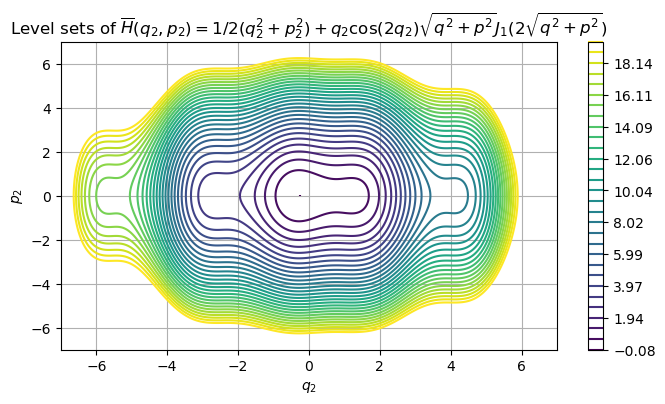

In [2]:
from scipy.special import j1

def averaged_hamiltonian(q2, p2, q, p):
    r = np.sqrt(q**2 + p**2)
    fac = r * j1(2*r)
    return 0.5 * (q2**2 + p2**2) + q2 * np.cos(2 * q2) * fac

# Create a grid of (q2, p2) values
q2 = np.linspace(-7, 7, 400)
p2 = np.linspace(-7, 7, 400)
Q, P = np.meshgrid(q2, p2)

# Calculate H_bar for each (q2, p2) pair
H = averaged_hamiltonian(Q, P, q=1.5, p=0)

# Plot the level sets
plt.figure(figsize=(8, 4))
levels = np.linspace(H.min(), H.max()-30, 30)
# levels = [0., 0.084, 0.171, 0.222, 0.288, 0.335, 0.414, 4., 10.]
contour = plt.contour(Q, P, H, levels=levels, cmap='viridis')
plt.colorbar(contour)
plt.title('Level sets of $\overline{H}(q_2, p_2) = 1/2 (q_2^2 + p_2^2) + q_2 \cos(2q_2) \sqrt{q^2 + p^2} J_1(2\sqrt{q^2 + p^2})$')
plt.xlabel('$q_2$')
plt.ylabel('$p_2$')
plt.grid(True)
plt.show()

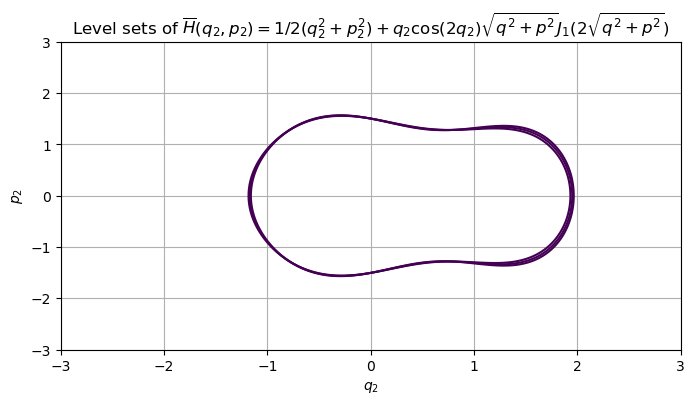

In [3]:
E = 1.129

q2 = np.linspace(-3, 3, 400)
p2 = np.linspace(-3, 3, 400)
Q, P = np.meshgrid(q2, p2)

plt.figure(figsize=(8, 4))

for (q, p) in [(1.5, 0), (-1.45, 0), (1., 0)]: 
    H = averaged_hamiltonian(Q, P, q=q, p=p)
    contour = plt.contour(Q, P, H, levels=[E], cmap='viridis')
    # plt.colorbar(contour)
plt.title('Level sets of $\overline{H}(q_2, p_2) = 1/2 (q_2^2 + p_2^2) + q_2 \cos(2q_2) \sqrt{q^2 + p^2} J_1(2\sqrt{q^2 + p^2})$')
plt.xlabel('$q_2$')
plt.ylabel('$p_2$')
plt.grid(True)
plt.show()

Target value of H is: 1.1299631512905242
Known values are: {'v1': 1.0, 'x1': 0.0, 'x2': 0.0}
The value of v2 that satisfies the equation is: 0.11224643881126242
The error (residual) of the solution is: -2.220446049250313e-16


## Reference trajectories with $u(0) = [0, 0, 1.5, q_2(0)]$

In [4]:
REF_TRAJ_DT = 0.05
REF_TRAJ_FILEPATHS = {
    1: "/workspace/projects_rui/learnsolnmap/out/nco/202405091928/ref/k=0/u.csv",
    2: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_1/ref/k=0/u.csv",
    3: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_2/ref/k=0/u.csv",
    4: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_3/ref/k=0/u.csv",
    5: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_4/ref/k=0/u.csv",
    6: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_5/ref/k=0/u.csv",
    7: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_6/ref/k=0/u.csv",
    8: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_7/ref/k=0/u.csv",
    11: "/workspace/projects_rui/learnsolnmap/out/nco/202405301406/ref/k=0/u.csv",
    12: "/workspace/projects_rui/learnsolnmap/out/nco/202406151238/ref/k=0/u.csv",
    13: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_8/ref/k=0/u.csv",
    14: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_9/ref/k=0/u.csv",
    15: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_10/ref/k=0/u.csv",
    16: "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_11/ref/k=0/u.csv",
}

In [5]:
# Global variables for the NCO reference trajectories

TRAJ_INDICES_DIFF_Q2 = {2, 3, 4, 5, 6, 7, 8, 13, 14, 15, 16}

for idx in TRAJ_INDICES_DIFF_Q2:
    ref_traj = Trajectory.load_from_file(REF_TRAJ_FILEPATHS[idx], dt=REF_TRAJ_DT)
    print(f"Traj {idx}: {ref_traj}, H = {NCO().compute_hamiltonian(ref_traj.uu[0])}")

Traj 2: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 0. ]), H = 1.125
Traj 3: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.   0.   1.5  0.15]), H = 1.1247575721881777
Traj 4: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 0.3]), H = 1.1234586580051733
Traj 5: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 0.4]), H = 1.1221288526543436
Traj 6: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 1. ]), H = 1.1156161358800527
Traj 7: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.   0.   1.5  1.45]), H = 1.1273806825399424
Traj 8: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.   0.   1.5  1.55]), H = 1.1327772217756737
Traj 13: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 4. ]), H = 1.1450005876069578
Traj 14: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 5. ]), H = 1.281512527761998
T

In [6]:
# Plotting function for reference trajectories

def plot_reference_trajs(traj_indices, t_range=None, phase_space_axis_lims=None):

    # Load the reference trajectories
    trajs = [Trajectory.load_from_file(REF_TRAJ_FILEPATHS[idx], REF_TRAJ_DT) for idx in traj_indices]
    legend_labels = [f"u0={traj.uu[0]}" for traj in trajs]

    # Select a time range if specified
    if t_range is not None:
        trajs = [traj.select_between(*t_range) for traj in trajs]

    # Plot the phase space
    plot_phase_space(trajs, axis_lims=phase_space_axis_lims, 
                     legend_labels=legend_labels, show_legend=True)
    
    # Plot phase space variables vs time
    q1_lim, p1_lim = phase_space_axis_lims[0]
    q2_lim, p2_lim = phase_space_axis_lims[1]
    plot_pq_vs_t(trajs, ylims=[q1_lim, q2_lim, p1_lim, p2_lim],
                 legend_labels=legend_labels, show_legend=True)

    return

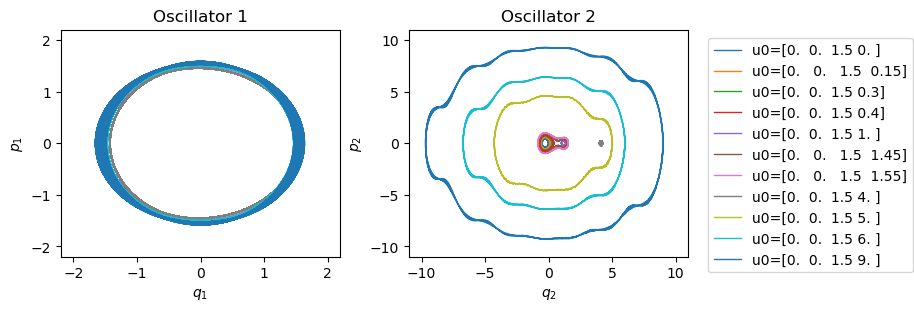

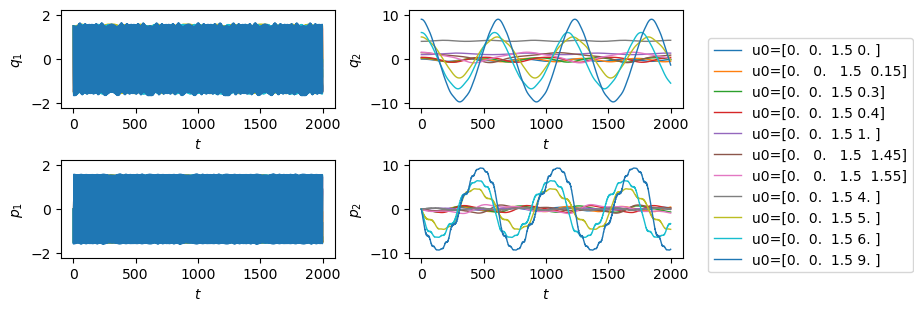

In [7]:
traj_indices = TRAJ_INDICES_DIFF_Q2
phase_space_axis_lims = [[(-2.2, 2.2), (-2.2, 2.2)], [(-11, 11), (-11, 11)]]

plot_reference_trajs(
    traj_indices, t_range=(0, 2000), phase_space_axis_lims=phase_space_axis_lims,
)


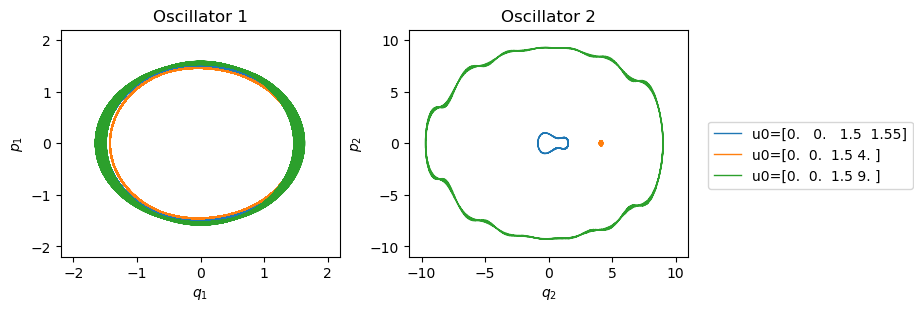

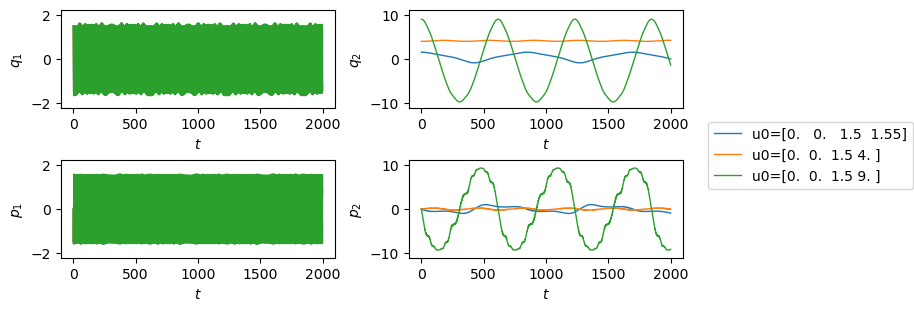

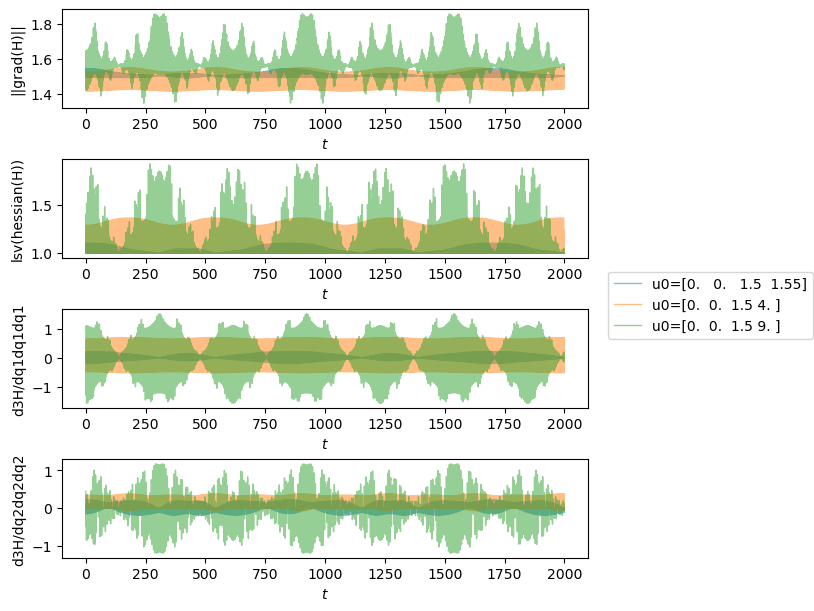

In [8]:
traj_indices = [8, 13, 16]
trajs = [Trajectory.load_from_file(REF_TRAJ_FILEPATHS[idx], REF_TRAJ_DT) for idx in traj_indices]
legend_labels = [f"u0={traj.uu[0]}" for traj in trajs]

plot_reference_trajs(
    traj_indices, t_range=(0, 2000), phase_space_axis_lims=phase_space_axis_lims,
)

nco = NCO()
func_dict = {
    "||grad(H)||": lambda u: np.linalg.norm(nco.compute_grad_H(u), axis=-1),
    "lsv(hessian(H))": lambda u: np.linalg.svd(nco.compute_hessian_H(u), compute_uv=False)[:, 0],
    # "d2H/dq1dq1": lambda u: nco.compute_hessian_H(u)[:, 2, 2],
    # "d2H/dq2dq2": lambda u: nco.compute_hessian_H(u)[:, 3, 3],
    # "d2H/dq1dq2": lambda u: nco.compute_hessian_H(u)[:, 2, 3],
    "d3H/dq1dq1dq1": nco.compute_d3Hdq1dq1dq1,
    "d3H/dq2dq2dq2": nco.compute_d3Hdq2dq2dq2,
    # "H": nco.compute_hamiltonian,
    # "V": nco.compute_potential_energy,
    # "K": nco.compute_kinetic_energy,
    # "V12": nco.compute_interaction_energy
}

plot_trace(trajs, func_dict, alpha=0.5, legend_labels=legend_labels, show_legend=True)

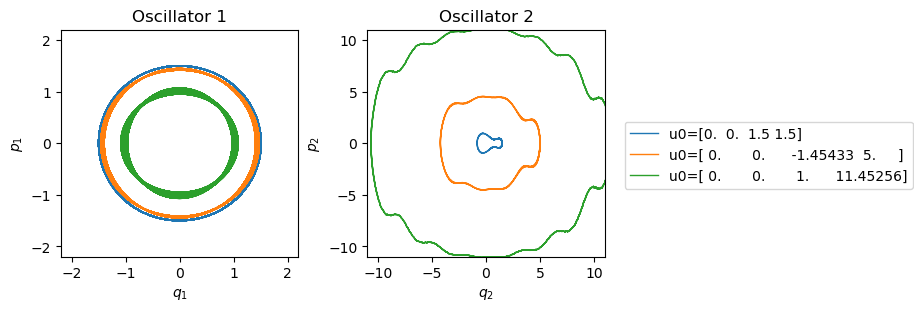

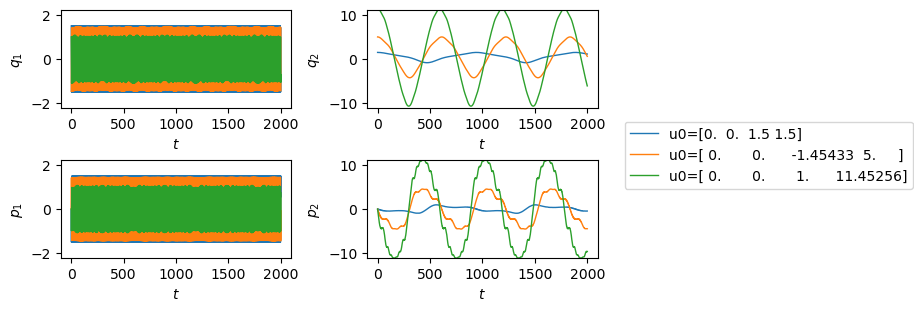

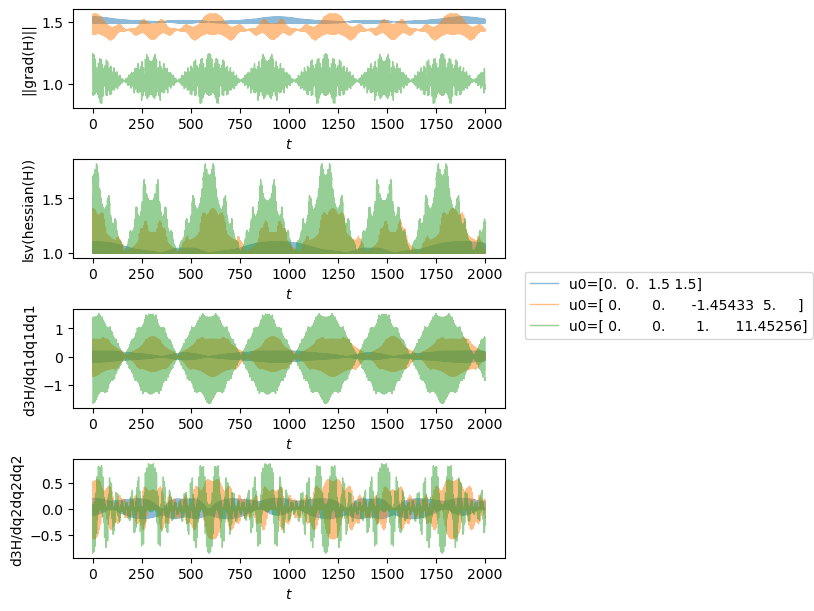

In [9]:
traj_indices = [1, 12, 11]
trajs = [Trajectory.load_from_file(REF_TRAJ_FILEPATHS[idx], REF_TRAJ_DT) for idx in traj_indices]
legend_labels = [f"u0={traj.uu[0]}" for traj in trajs]

plot_reference_trajs(
    traj_indices, t_range=(0, 2000), phase_space_axis_lims=phase_space_axis_lims,
)

nco = NCO()
func_dict = {
    "||grad(H)||": lambda u: np.linalg.norm(nco.compute_grad_H(u), axis=-1),
    "lsv(hessian(H))": lambda u: np.linalg.svd(nco.compute_hessian_H(u), compute_uv=False)[:, 0],
    # "d2H/dq1dq1": lambda u: nco.compute_hessian_H(u)[:, 2, 2],
    # "d2H/dq2dq2": lambda u: nco.compute_hessian_H(u)[:, 3, 3],
    # "d2H/dq1dq2": lambda u: nco.compute_hessian_H(u)[:, 2, 3],
    "d3H/dq1dq1dq1": nco.compute_d3Hdq1dq1dq1,
    "d3H/dq2dq2dq2": nco.compute_d3Hdq2dq2dq2,
    # "H": nco.compute_hamiltonian,
    # "V": nco.compute_potential_energy,
    # "K": nco.compute_kinetic_energy,
    # "V12": nco.compute_interaction_energy
}

plot_trace(trajs, func_dict, alpha=0.5, legend_labels=legend_labels, show_legend=True)

## Curvature of $H$

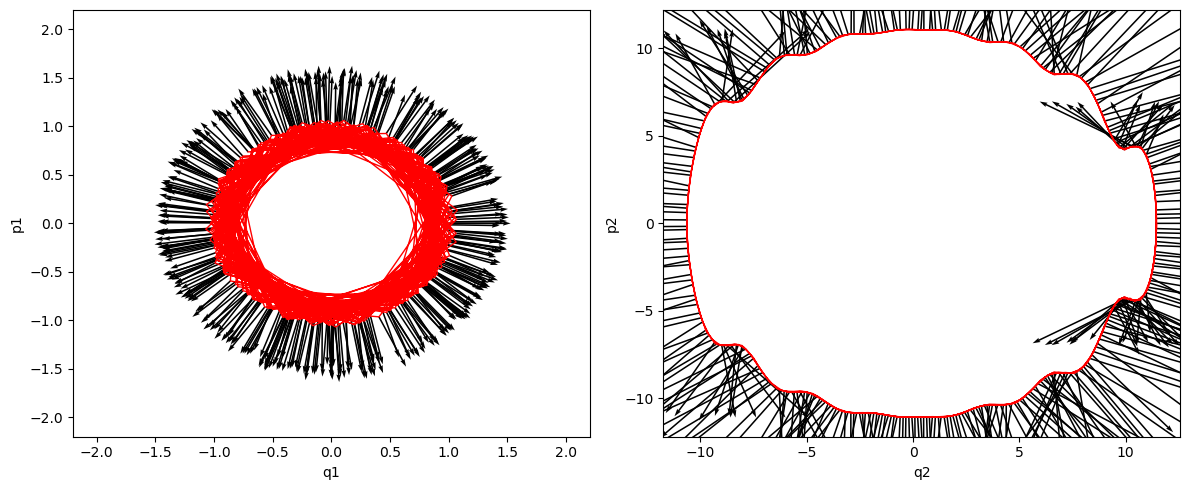

In [58]:
epsilon = 0.01
u_ref = u_ref2 
grad_H = grad_H2

indices_ref = np.arange(len(u_ref1))[::100]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(u_ref[indices_ref, 2], u_ref[indices_ref, 0], "-", lw=1, color="r")
plt.quiver(u_ref[indices_ref, 2], u_ref[indices_ref, 0], 
            grad_H[indices_ref, 2], grad_H[indices_ref, 0], scale=10)
plt.xlim(-2.2, 2.2)
plt.ylim(-2.2, 2.2)
plt.xlabel("q1")
plt.ylabel("p1")
# plt.legend()

plt.subplot(1, 2, 2)
plt.plot(u_ref[indices_ref, 3], u_ref[indices_ref, 1]/epsilon, "-", lw=1, color="r")
plt.quiver(u_ref[indices_ref, 3], u_ref[indices_ref, 1]/epsilon, 
            grad_H[indices_ref, 3], grad_H[indices_ref, 1], scale=0.5)
# plt.xlim(-2., 2)
# plt.ylim(-0.018, 0.018)
plt.xlabel("q2")
plt.ylabel("p2")
# plt.legend()

plt.tight_layout()
plt.show()